# 07 — POST relevance × episode interaction

This notebook tests whether the relevance effect differs across island episodes.

The POST-only first-level GLM models:

```text
post_oldRelE1
post_oldIrrelE1
post_oldRelE2
post_oldIrrelE2
post_oldRelE3
post_oldIrrelE3
post_new
```

The key interaction contrasts compare the relevance effect between episodes, for example:

$$
(\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}})
-
(\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}).
$$

The notebook is restart-safe:

- first-level maps are saved immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing subjects;
- all figures use the common high-resolution mean T1w anatomical background from Notebook 00, passed directly as `bg_img`.


In [14]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from nilearn.image import load_img
from nilearn.plotting import plot_design_matrix

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.events import (
    save_post_relevance_episode_subject_events,
    build_post_relevance_episode_event_qc,
    make_post_relevance_episode_events,
)
from island_glm.contrasts import (
    make_post_relevance_episode_contrasts,
    contrast_specs_to_table,
)
from island_glm.first_level import run_post_relevance_episode_first_level_subject
from island_glm.second_level import (
    first_level_map_path,
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table
from island_glm.plotting import plot_group_stat_map, make_interactive_view

ANALYSIS_NAME = "post_relevance_episode_interaction_viewing_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------

# First run of this new notebook: keep RUN_FIRST_LEVEL=True.
# After all maps are saved successfully, change it to False.
RUN_FIRST_LEVEL = True
OVERWRITE_FIRST_LEVEL = True

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])
print("dirs keys:", sorted(dirs.keys()))


Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm
dirs keys: ['cluster_tables', 'events', 'figures', 'first_level', 'first_level_designs', 'first_level_figures', 'first_level_maps', 'interactive', 'out', 'restart', 'second_level', 'second_level_maps', 'tables', 'thresholded_maps']


## Load common inputs from Notebook 00

Notebook 00 defines the final subject list, viewing item labels, filename parsing, relevance labels, episode labels, checkpoint labels, and the common mean T1w anatomical background.


In [15]:
# ============================================================
# 2. Load common inputs and mean T1w background
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

assert "mean_anat" in manifest, (
    "Mean anatomical background missing from manifest. "
    "Rerun Notebook 00 after adding the mean T1w section."
)

mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
assert mean_t1w_path.exists(), f"Missing mean T1w file: {mean_t1w_path}"
mean_t1w_img = load_img(str(mean_t1w_path))

print("\nLoaded mean T1w anatomical background:")
print(mean_t1w_path)
print("Mean T1w shape:", mean_t1w_img.shape)

display(subject_table)
display(viewing_item_labels.head())

required_columns = {"subject", "phase", "onset", "duration", "old_new", "episode", "relevance"}
missing_columns = required_columns.difference(viewing_item_labels.columns)
assert not missing_columns, f"Missing expected columns in viewing_item_labels: {missing_columns}"


Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}

Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early


## Scientific question

This notebook asks whether the neural relevance effect depends on the episode in which an old image was encountered on the island.

The basic within-episode relevance effects are:

$$
C_{\mathrm{rel>irrel,E1}}
=
\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}},
$$

$$
C_{\mathrm{rel>irrel,E2}}
=
\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}},
$$

$$
C_{\mathrm{rel>irrel,E3}}
=
\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}.
$$

The interaction contrasts compare these relevance effects across episodes.


## Contrasts

The notebook includes the average relevance effect across episodes:

$$
\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post,oldRelE2}}+\beta_{\mathrm{post,oldRelE3}})
-

\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}}).
$$

It also includes each episode-specific relevance effect:

$$
\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}},\quad
\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}},\quad
\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}.
$$

Finally, it includes all ordered pairwise relevance-by-episode interactions:

$$
(\mathrm{Rel>Irrel})_{E1}>(\mathrm{Rel>Irrel})_{E2},\quad
(\mathrm{Rel>Irrel})_{E2}>(\mathrm{Rel>Irrel})_{E1},
$$

$$
(\mathrm{Rel>Irrel})_{E1}>(\mathrm{Rel>Irrel})_{E3},\quad
(\mathrm{Rel>Irrel})_{E3}>(\mathrm{Rel>Irrel})_{E1},
$$

$$
(\mathrm{Rel>Irrel})_{E2}>(\mathrm{Rel>Irrel})_{E3},\quad
(\mathrm{Rel>Irrel})_{E3}>(\mathrm{Rel>Irrel})_{E2}.
$$


In [16]:
# ============================================================
# 3. Define relevance × episode contrasts
# ============================================================

contrast_specs = make_post_relevance_episode_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)


,contrast,priority,formula,interpretation,post_oldRelE1,post_oldIrrelE1,post_oldRelE2,post_oldIrrelE2,post_oldRelE3,post_oldIrrelE3,post_new
0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",POST relevant old images > irrelevant old images within E1.,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE1}}-\beta_{\mathrm{post,oldRelE1}}$$",POST irrelevant old images > relevant old images within E1.,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",POST relevant old images > irrelevant old images within E2.,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.0
3,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE2}}-\beta_{\mathrm{post,oldRelE2}}$$",POST irrelevant old images > relevant old images within E2.,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,0.0
4,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}$$",POST relevant old images > irrelevant old images within E3.,0.000000,0.000000,0.000000,0.000000,1.000000,-1.000000,0.0
5,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE3}}-\beta_{\mathrm{post,oldRelE3}}$$",POST irrelevant old images > relevant old images within E3.,0.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.0
6,post_rel_gt_irrel_avg,07_average_relevance_effect,"$$\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post,oldRelE2}}+\beta_{\mathrm{post,oldRelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,old...","POST relevant old images > irrelevant old images, averaged across episodes.",0.333333,-0.333333,0.333333,-0.333333,0.333333,-0.333333,0.0
7,post_irrel_gt_rel_avg,07_average_reverse_control,"$$\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post...","POST irrelevant old images > relevant old images, averaged across episodes.",-0.333333,0.333333,-0.333333,0.333333,-0.333333,0.333333,0.0
8,post_relIrrel_e1_gt_e2,07_relevance_by_episode_interaction,"$$(\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}})-(\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}})$$",Relevance effect in E1 > relevance effect in E2.,1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000,0.0
9,post_relIrrel_e2_gt_e1,07_relevance_by_episode_interaction,"$$(\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}})-(\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}})$$",Relevance effect in E2 > relevance effect in E1.,-1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,0.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_contrast_definitions.csv


## Event relabelling

We create one clean POST event table per subject with four BIDS-compatible columns:

```text
onset, duration, trial_type, modulation
```

Trial types are:

```text
post_oldRelE1
post_oldIrrelE1
post_oldRelE2
post_oldIrrelE2
post_oldRelE3
post_oldIrrelE3
post_new
post_other
```


In [17]:
# ============================================================
# 4. Build POST relevance × episode event files and event-count QC
# ============================================================

for subject in subjects:
    save_post_relevance_episode_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
        phase="post",
    )

event_qc, all_events_long = build_post_relevance_episode_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
    phase="post",
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="	", index=False)

display(event_qc)
print("Saved event QC:", event_qc_path)
print("Saved long event table:", all_events_path)

expected_cols = [
    "n_post_oldRelE1", "n_post_oldIrrelE1",
    "n_post_oldRelE2", "n_post_oldIrrelE2",
    "n_post_oldRelE3", "n_post_oldIrrelE3",
    "n_post_new",
]

for col in expected_cols:
    assert col in event_qc.columns, f"Missing QC column: {col}"
    assert (event_qc[col] > 0).all(), f"Some subjects have zero events for {col}"

assert (event_qc["n_post_other"] == 0).all(), "Unexpected post_other trials found. Inspect event QC."
print("Event-count QC passed.")


,subject,phase,n_events,events_path,n_post_oldRelE1,n_post_oldIrrelE1,n_post_oldRelE2,n_post_oldIrrelE2,n_post_oldRelE3,n_post_oldIrrelE3,n_post_new,n_post_other
0,sub-P10,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P10_post_task-viewing_po...,48,48,48,48,48,48,96,0
1,sub-P12,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P12_post_task-viewing_po...,48,48,48,48,48,48,96,0
2,sub-P13,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P13_post_task-viewing_po...,48,48,48,48,48,48,96,0
3,sub-P14,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P14_post_task-viewing_po...,48,48,48,48,48,48,96,0
4,sub-P15,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P15_post_task-viewing_po...,48,48,48,48,48,48,96,0
5,sub-P16,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P16_post_task-viewing_po...,48,48,48,48,48,48,96,0
6,sub-P17,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P17_post_task-viewing_po...,48,48,48,48,48,48,96,0
7,sub-P18,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P18_post_task-viewing_po...,48,48,48,48,48,48,96,0
8,sub-P19,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P19_post_task-viewing_po...,48,48,48,48,48,48,96,0
9,sub-P21,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/sub-P21_post_task-viewing_po...,48,48,48,48,48,48,96,0


Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_event_count_qc.csv
Saved long event table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_relevance_episode_interaction_viewing_glm/all_subjects_post_relevance_episode_interaction_viewing_glm_events_long.tsv
Event-count QC passed.


## Single-subject design preview

Before running all subjects, we fit one example subject and inspect the design matrix and contrast vectors. This cell does **not** save first-level contrast maps.


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Subject QC preview:


,subject,phase,session,tr,n_scans,n_events,event_types,n_confounds,sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns,design_columns
0,sub-P15,post,ses-05,1.3,1995,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,65,True,False,73,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...


Contrast-vector preview:


,subject,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,sub-P15,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,1,73,2,post_oldIrrelE1;post_oldRelE1,-1.0;1.0,,False
1,sub-P15,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,1,73,2,post_oldIrrelE1;post_oldRelE1,1.0;-1.0,,False
2,sub-P15,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,1,73,2,post_oldIrrelE2;post_oldRelE2,-1.0;1.0,,False
3,sub-P15,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,1,73,2,post_oldIrrelE2;post_oldRelE2,1.0;-1.0,,False
4,sub-P15,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,1,73,2,post_oldIrrelE3;post_oldRelE3,-1.0;1.0,,False
5,sub-P15,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,1,73,2,post_oldIrrelE3;post_oldRelE3,1.0;-1.0,,False
6,sub-P15,post_rel_gt_irrel_avg,07_average_relevance_effect,1,73,6,post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,-0.3333333333333333;-0.3333333333333333;-0.3333333333333333;0.3333333333333333;0.3333333333333333;0.3333333333333333,,False
7,sub-P15,post_irrel_gt_rel_avg,07_average_reverse_control,1,73,6,post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,0.3333333333333333;0.3333333333333333;0.3333333333333333;-0.3333333333333333;-0.3333333333333333;-0.3333333333333333,,False
8,sub-P15,post_relIrrel_e1_gt_e2,07_relevance_by_episode_interaction,1,73,4,post_oldIrrelE1;post_oldIrrelE2;post_oldRelE1;post_oldRelE2,-1.0;1.0;1.0;-1.0,,False
9,sub-P15,post_relIrrel_e2_gt_e1,07_relevance_by_episode_interaction,1,73,4,post_oldIrrelE1;post_oldIrrelE2;post_oldRelE1;post_oldRelE2,1.0;-1.0;-1.0;1.0,,False


sub-P15 — design matrix run 1
Shape: (1995, 73)
Task regressors:
['post_new', 'post_oldIrrelE1', 'post_oldIrrelE2', 'post_oldIrrelE3', 'post_oldRelE1', 'post_oldRelE2', 'post_oldRelE3']


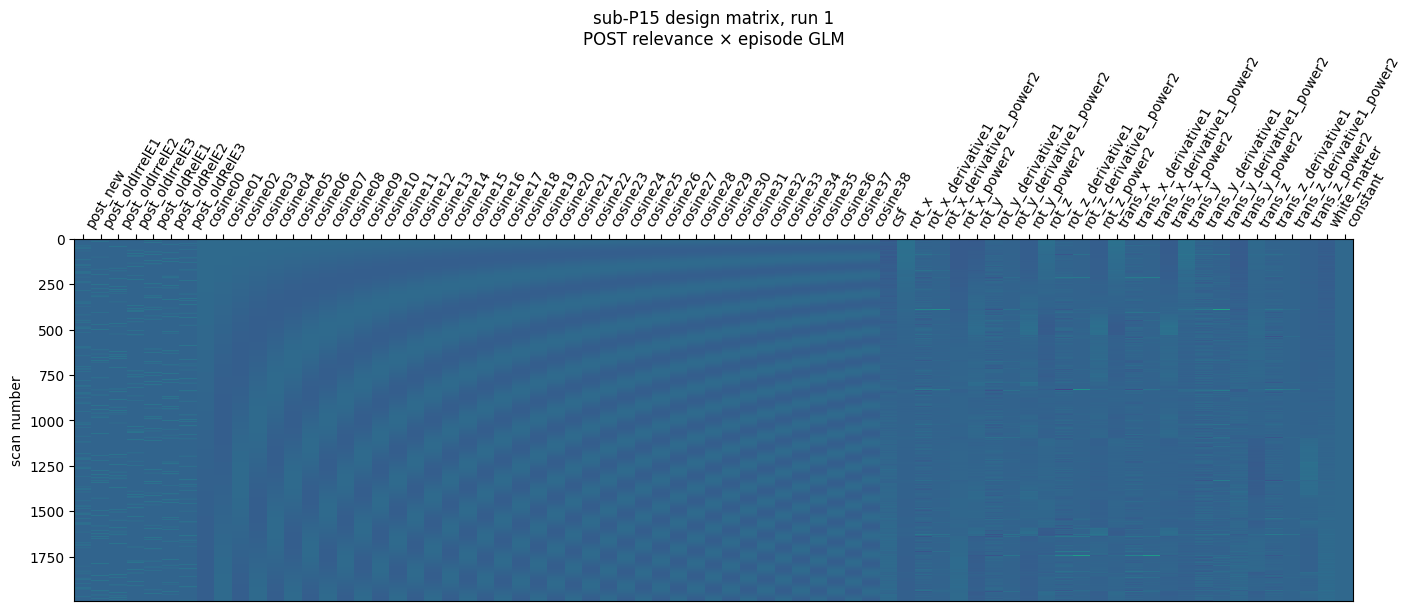

Saved design matrix CSV: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/design_matrices/post_relevance_episode_interaction_viewing_glm_sub-P15_run-1_design_matrix_smoothed5mm.csv
Saved design matrix figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/design_matrices/post_relevance_episode_interaction_viewing_glm_sub-P15_run-1_design_matrix_smoothed5mm.png
Design and contrast-vector preview passed.


In [18]:
# ============================================================
# 5. Single-subject design and contrast preview
# ============================================================

preview_result = run_post_relevance_episode_first_level_subject(
    subject=TEST_SUBJECT,
    paths=paths,
    viewing_item_labels=viewing_item_labels,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=False,
    return_model=True,
)

preview_subject_qc = preview_result["subject_qc"]
preview_contrast_qc = preview_result["contrast_qc"]
design_matrices = preview_result["design_matrices"]

preview_subject_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
)
preview_contrast_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"
)

preview_subject_qc.to_csv(preview_subject_qc_path, index=False)
preview_contrast_qc.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(preview_subject_qc)

print("Contrast-vector preview:")
display(preview_contrast_qc)

assert not preview_contrast_qc.groupby("contrast")["is_null_vector"].all().any()

design_matrix_dir = dirs["figures"] / "design_matrices"
design_matrix_dir.mkdir(parents=True, exist_ok=True)

design_matrix_table_dir = dirs["tables"] / "design_matrices"
design_matrix_table_dir.mkdir(parents=True, exist_ok=True)

for run_idx, design_matrix in enumerate(design_matrices, start=1):
    print("=" * 80)
    print(f"{TEST_SUBJECT} — design matrix run {run_idx}")
    print("Shape:", design_matrix.shape)

    task_columns = [
        col for col in design_matrix.columns
        if col.startswith("post_")
    ]

    print("Task regressors:")
    print(task_columns)

    design_matrix_csv_path = (
        design_matrix_table_dir
        / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
    )
    design_matrix.to_csv(design_matrix_csv_path)

    # This Nilearn version does not support ax=..., so use plt.gcf().
    plot_design_matrix(design_matrix)
    fig = plt.gcf()
    fig.set_size_inches(14, 6)

    plt.title(
        f"{TEST_SUBJECT} design matrix, run {run_idx}\n"
        "POST relevance × episode GLM"
    )

    design_matrix_fig_path = (
        design_matrix_dir
        / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
    )

    fig.savefig(design_matrix_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved design matrix CSV:", design_matrix_csv_path)
    print("Saved design matrix figure:", design_matrix_fig_path)

print("Design and contrast-vector preview passed.")


## Restart-safe first-level GLM

The first-level GLM is the slow part. This notebook is configured so that:

- `RUN_FIRST_LEVEL=True` fits first-level models and saves maps immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing or incomplete subjects.

After a successful first run, keep `RUN_FIRST_LEVEL=False`.


In [19]:
# ============================================================
# 6. Run, recover, or load first-level GLM results
# ============================================================

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"


def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
        effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


def recover_first_level_qc_from_saved_maps(subjects, contrast_specs, dirs, smoothing_label):
    recovered_map_rows = []
    recovered_qc_rows = []
    recovered_contrast_rows = []

    for subject in subjects:
        subject_all_maps_exist = True
        for contrast_name in contrast_specs.keys():
            z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
            effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")

            z_exists = z_path.exists()
            effect_exists = effect_path.exists()
            if not z_exists or not effect_exists:
                subject_all_maps_exist = False

            recovered_map_rows.append({
                "contrast": contrast_name,
                "n_z_maps": int(z_exists),
                "n_effect_maps": int(effect_exists),
                "missing_z_maps": "" if z_exists else subject,
                "missing_effect_maps": "" if effect_exists else subject,
            })

            recovered_contrast_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
                "recovered_from_saved_maps": True,
            })

        recovered_qc_rows.append({
            "subject": subject,
            "all_expected_first_level_maps_exist": subject_all_maps_exist,
            "recovered_from_saved_maps": True,
        })

    first_level_qc = pd.DataFrame(recovered_qc_rows)
    first_level_contrast_qc = pd.DataFrame(recovered_contrast_rows)

    failed_subjects = first_level_qc.loc[
        ~first_level_qc["all_expected_first_level_maps_exist"],
        ["subject"],
    ].copy()

    if len(failed_subjects) > 0:
        failed_subjects["error_type"] = "MissingFirstLevelMaps"
        failed_subjects["error_message"] = "At least one expected first-level z/effect map is missing."
    else:
        failed_subjects = pd.DataFrame(columns=["subject", "error_type", "error_message"])

    return first_level_qc, first_level_contrast_qc, failed_subjects


existing_subjects = [
    subject
    for subject in subjects
    if subject_has_all_first_level_maps(subject, contrast_specs, dirs, SMOOTHING_LABEL)
]
missing_subjects = [subject for subject in subjects if subject not in existing_subjects]

print("Existing complete first-level subjects:", len(existing_subjects))
print("Missing/incomplete first-level subjects:", len(missing_subjects))
if missing_subjects:
    print("Missing/incomplete:", missing_subjects)

if RUN_FIRST_LEVEL:
    if OVERWRITE_FIRST_LEVEL:
        subjects_to_run = subjects
        print("\nOVERWRITE_FIRST_LEVEL=True, rerunning all subjects.")
    else:
        subjects_to_run = missing_subjects
        print("\nOVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.")

    first_level_qc_rows = []
    first_level_contrast_qc_rows = []
    failed_rows = []

    for subject in subjects_to_run:
        print("=" * 80)
        print("Running POST relevance × episode first-level GLM:", subject)
        try:
            subject_qc, contrast_qc = run_post_relevance_episode_first_level_subject(
                subject=subject,
                paths=paths,
                viewing_item_labels=viewing_item_labels,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )
            first_level_qc_rows.append(subject_qc)
            first_level_contrast_qc_rows.append(contrast_qc)
            print("Finished:", subject)
        except Exception as exc:
            failed_rows.append({
                "subject": subject,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            })
            print("FAILED:", subject, type(exc).__name__, str(exc))

    new_first_level_qc = pd.concat(first_level_qc_rows, ignore_index=True) if first_level_qc_rows else pd.DataFrame()
    new_first_level_contrast_qc = pd.concat(first_level_contrast_qc_rows, ignore_index=True) if first_level_contrast_qc_rows else pd.DataFrame()
    failed_subjects = pd.DataFrame(failed_rows)

    if first_level_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_qc = pd.concat([old_first_level_qc, new_first_level_qc], ignore_index=True)
        if "subject" in first_level_qc.columns:
            first_level_qc = first_level_qc.drop_duplicates(subset=["subject"], keep="last")
    else:
        first_level_qc = new_first_level_qc

    if first_level_contrast_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        first_level_contrast_qc = pd.concat([old_first_level_contrast_qc, new_first_level_contrast_qc], ignore_index=True)
        dedup_cols = [col for col in ["subject", "contrast", "run"] if col in first_level_contrast_qc.columns]
        if dedup_cols:
            first_level_contrast_qc = first_level_contrast_qc.drop_duplicates(subset=dedup_cols, keep="last")
    else:
        first_level_contrast_qc = new_first_level_contrast_qc

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
    failed_subjects.to_csv(failed_subjects_path, index=False)
else:
    print("\nRUN_FIRST_LEVEL=False, loading or recovering existing first-level outputs.")
    if first_level_qc_path.exists() and first_level_contrast_qc_path.exists():
        first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        failed_subjects = pd.read_csv(failed_subjects_path) if failed_subjects_path.exists() else pd.DataFrame(columns=["subject", "error_type", "error_message"])
    else:
        print("QC tables missing; recovering from saved first-level maps.")
        first_level_qc, first_level_contrast_qc, failed_subjects = recover_first_level_qc_from_saved_maps(
            subjects, contrast_specs, dirs, SMOOTHING_LABEL
        )
        first_level_qc.to_csv(first_level_qc_path, index=False)
        first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
        failed_subjects.to_csv(failed_subjects_path, index=False)

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
assert (map_qc["n_z_maps"] == len(subjects)).all(), (
    "Some first-level z-maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)
assert (map_qc["n_effect_maps"] == len(subjects)).all(), (
    "Some first-level effect maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)

print("\nFirst-level ready.")
print("Failed subjects:", len(failed_subjects))
display(first_level_qc)
display(failed_subjects)
assert len(failed_subjects) == 0, "Some subjects failed. Inspect failed_subjects."


Existing complete first-level subjects: 0
Missing/incomplete first-level subjects: 27
Missing/incomplete: ['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

OVERWRITE_FIRST_LEVEL=True, rerunning all subjects.
Running POST relevance × episode first-level GLM: sub-P10


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P10
Running POST relevance × episode first-level GLM: sub-P12
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P12
Running POST relevance × episode first-level GLM: sub-P13
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P13
Running POST relevance × episode first-level GLM: sub-P14
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P14
Running POST relevance × episode first-level GLM: sub-P15
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P15
Running POST relevance × episode first-level GLM: sub-P16
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P16
Running POST relevance × episode first-level GLM: 

,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,27,27,27
1,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,27,27,27
2,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,27,27,27
3,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,27,27,27
4,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,27,27,27
5,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,27,27,27
6,post_rel_gt_irrel_avg,07_average_relevance_effect,27,27,27
7,post_irrel_gt_rel_avg,07_average_reverse_control,27,27,27
8,post_relIrrel_e1_gt_e2,07_relevance_by_episode_interaction,27,27,27
9,post_relIrrel_e2_gt_e1,07_relevance_by_episode_interaction,27,27,27



First-level ready.
Failed subjects: 0


,subject,phase,session,tr,n_scans,n_events,event_types,n_confounds,sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns,design_columns
0,sub-P10,post,ses-05,1.3,1994,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,65,True,False,73,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
1,sub-P12,post,ses-05,1.3,1954,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
2,sub-P13,post,ses-05,1.3,1957,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
3,sub-P14,post,ses-05,1.3,1922,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
4,sub-P15,post,ses-05,1.3,1995,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,65,True,False,73,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
5,sub-P16,post,ses-05,1.3,1955,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
6,sub-P17,post,ses-05,1.3,1946,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
7,sub-P18,post,ses-05,1.3,1993,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,65,True,False,73,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
8,sub-P19,post,ses-05,1.3,1945,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...
9,sub-P21,post,ses-05,1.3,1961,384,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3,64,True,False,72,post_new;post_oldIrrelE1;post_oldIrrelE2;post_oldIrrelE3;post_oldRelE1;post_oldRelE2;post_oldRelE3;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosin...


""


## Verify first-level maps

Each contrast should have one z-map and one effect-size map per subject.


In [21]:
# ============================================================
# 7. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,27,27,27
1,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,27,27,27
2,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,27,27,27
3,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,27,27,27
4,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,27,27,27
5,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,27,27,27
6,post_rel_gt_irrel_avg,07_average_relevance_effect,27,27,27
7,post_irrel_gt_rel_avg,07_average_reverse_control,27,27,27
8,post_relIrrel_e1_gt_e2,07_relevance_by_episode_interaction,27,27,27
9,post_relIrrel_e2_gt_e1,07_relevance_by_episode_interaction,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_first_level_map_qc_smoothed5mm.csv


## Second-level GLM

At the group level, each first-level effect map enters a one-sample test against zero.


In [22]:
# ============================================================
# 8. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")
        second_level_table = pd.read_csv(second_level_table_path)
    else:
        print("Running second-level GLM.")
        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )
        second_level_table.to_csv(second_level_table_path, index=False)
else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")
    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )
    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()


Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
1,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE1}}-\beta_{\mathrm{post,oldRelE1}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
2,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
3,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE2}}-\beta_{\mathrm{post,oldRelE2}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
4,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
5,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE3}}-\beta_{\mathrm{post,oldRelE3}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
6,post_rel_gt_irrel_avg,07_average_relevance_effect,"$$\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post,oldRelE2}}+\beta_{\mathrm{post,oldRelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,old...",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/maps/group_pos...,True,True
7,post_irrel_gt_rel_avg,07_average_reverse_control,"$$\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post...",27,/media/RCPNAS/Data3/Alison_island/kroczak/isla

Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_second_level_maps_smoothed5mm.csv


## Thresholding and cluster tables

We save corrected threshold summaries and exploratory cluster tables. Visualizations use exploratory thresholds unless corrected maps survive FDR/Bonferroni.


In [23]:
# ============================================================
# 9. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(2.33, 3.0),
    cluster_threshold_voxels=10,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary.sort_values(["contrast", "threshold_label"]))

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.557127952575684. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.557127952575684. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.557127952575684. But, you have given threshold=4.944046259789629.
  t

Threshold summary:


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:231: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_tables, ignore_index=True)


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
31,post_irrel_gt_rel_avg,07_average_reverse_control,"$$\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post...",bonferroni_p05_one_sided,bonferroni,0.050,False,4.944046,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
29,post_irrel_gt_rel_avg,07_average_reverse_control,"$$\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post...",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
30,post_irrel_gt_rel_avg,07_average_reverse_control,"$$\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post...",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
28,post_irrel_gt_rel_avg,07_average_reverse_control,"$$\frac{1}{3}(\beta_{\mathrm{post,oldIrrelE1}}+\beta_{\mathrm{post,oldIrrelE2}}+\beta_{\mathrm{post,oldIrrelE3}})-\frac{1}{3}(\beta_{\mathrm{post,oldRelE1}}+\beta_{\mathrm{post...",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,30,3.746916,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
7,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,"$$\beta_{\mathrm{post,oldIrrelE1}}-\beta_{\mathrm{post,oldRelE1}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.944046,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
...,...,...,...,...,...,...,...,...,...,...,...
8,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,51,3.772909,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
19,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.944046,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
17,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...
18,post_rel_gt_irrel_e3,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE3}}-\beta_{\mathrm{post,oldIrrelE3}}$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/thresholded_ma...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
14,post_irrel_gt_rel_avg,07_average_reverse_control,z_gt_2.33,2.33,10,7,3.746916,359.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
15,post_irrel_gt_rel_avg,07_average_reverse_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
2,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,z_gt_2.33,2.33,10,3,3.833682,187.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
3,post_irrel_gt_rel_e1,07_episode_specific_reverse_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
6,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,z_gt_2.33,2.33,10,11,3.925017,875.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
7,post_irrel_gt_rel_e2,07_episode_specific_reverse_control,z_gt_3.00,3.00,10,1,3.925017,265.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
10,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,z_gt_2.33,2.33,10,11,3.971288,359.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
11,post_irrel_gt_rel_e3,07_episode_specific_reverse_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
30,post_oldIrrelE1_gt_new,07_irrelevant_episode_vs_new_control,z_gt_2.33,2.33,10,17,4.147337,968.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...
31,post_oldIrrelE1_gt_new,07_irrelevant_episode_vs_new_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/second_level_from_smoothed5mm/cluster_tables...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_cluster_details_smoothed5mm.csv


## Atlas labels for exploratory peaks

The cluster table is labelled with Harvard-Oxford. These labels are useful for reporting, but exact anatomy should still be checked visually.


In [24]:
# ============================================================
# 10. Label cluster table with Harvard-Oxford atlas
# ============================================================

cluster_details_labeled = label_cluster_table(cluster_details)
cluster_details_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_labeled_{SMOOTHING_LABEL}.csv"
cluster_details_labeled.to_csv(cluster_details_labeled_path, index=False)

display(cluster_details_labeled.head(80))
print("Saved:", cluster_details_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,21.5,-72.0,-35.5,4.069502,187.0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",z_gt_2.33,2.33,10,Background,0,Background,0
1,2,19.0,-34.5,-30.5,3.903922,187.0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",z_gt_2.33,2.33,10,Background,0,Brain-Stem,8
2,3,36.5,53.0,-8.0,3.699215,2328.0,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral Cortex,13
3,3a,39.0,45.5,-3.0,3.508600,NaN,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral White Matter,12
4,3b,49.0,48.0,-0.5,3.380451,NaN,post_rel_gt_irrel_e1,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE1}}-\beta_{\mathrm{post,oldIrrelE1}}$$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral Cortex,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,11a,-48.5,-39.5,62.0,2.805972,NaN,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",z_gt_2.33,2.33,10,Background,0,Background,0
76,12,-21.0,-87.0,-10.5,2.886382,171.0,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",z_gt_2.33,2.33,10,Occipital Fusiform Gyrus,40,Left Cerebral Cortex,2
77,13,-1.0,10.5,17.0,2.848965,218.0,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",z_gt_2.33,2.33,10,Background,0,Left Lateral Ventricle,3
78,13a,-1.0,3.0,9.5,2.513511,NaN,post_rel_gt_irrel_e2,07_episode_specific_relevance_effect,"$$\beta_{\mathrm{post,oldRelE2}}-\beta_{\mathrm{post,oldIrrelE2}}$$",z_gt_2.33,2.33,10,Background,0,Left Lateral Ventricle,3


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_cluster_details_labeled_smoothed5mm.csv


## Plot relevance × episode contrasts on the common mean T1w background

The high-resolution mean T1w from Notebook 00 is passed directly as `bg_img`. We do **not** manually resample it to the z-map grid.


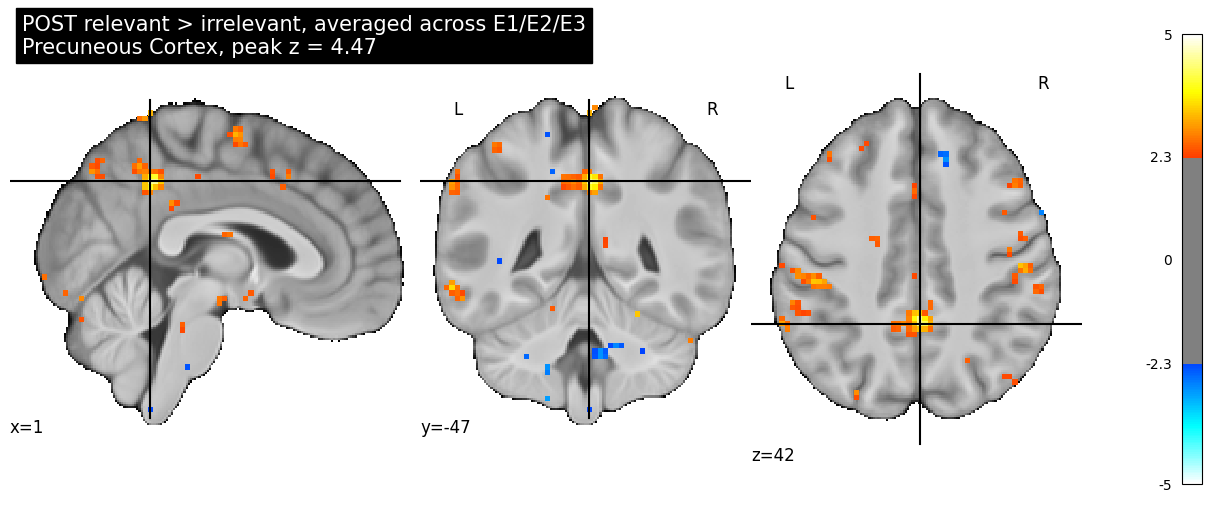

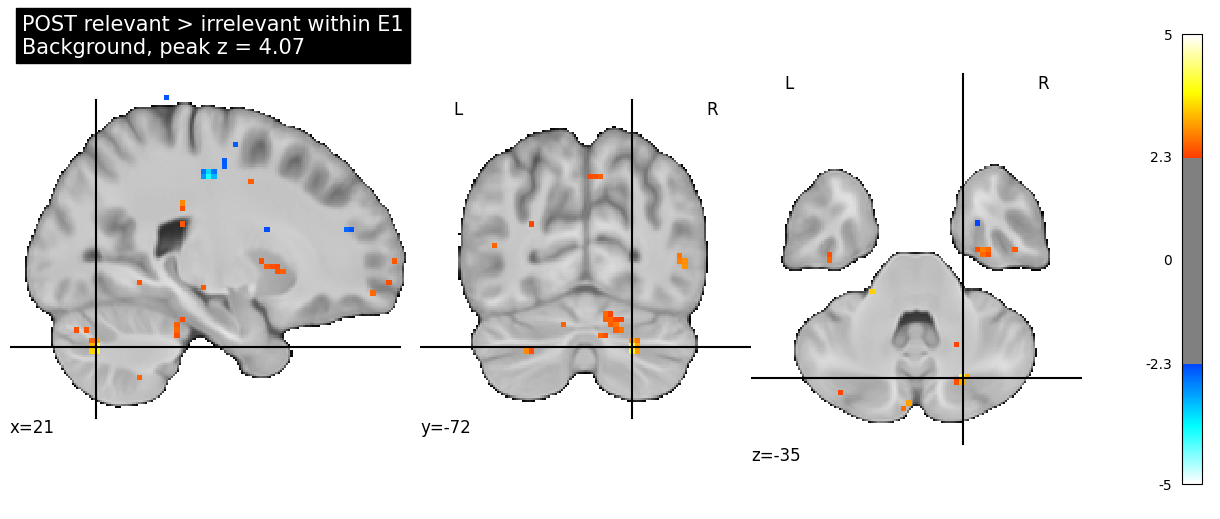

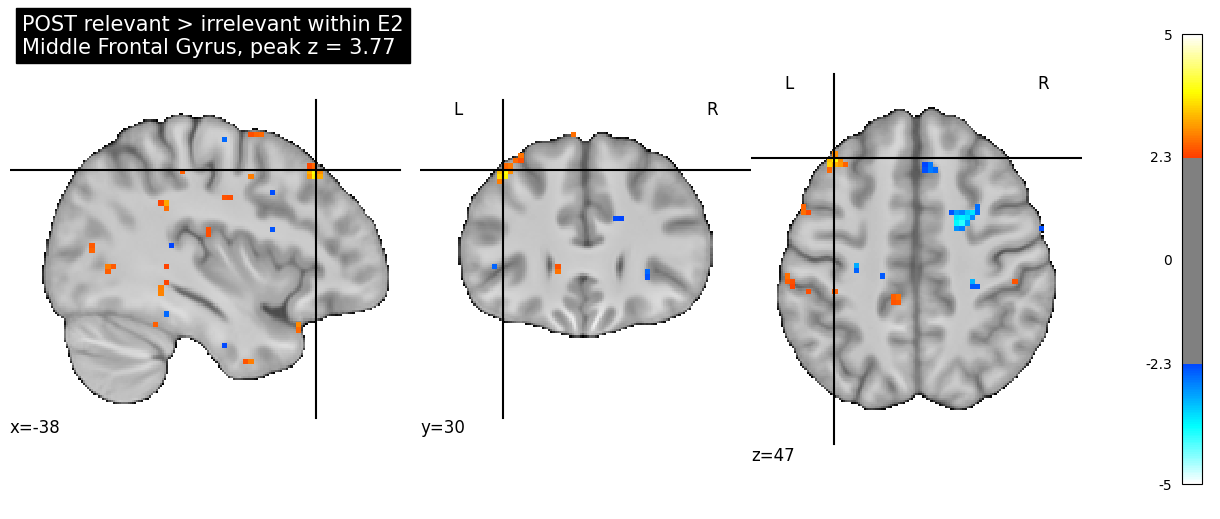

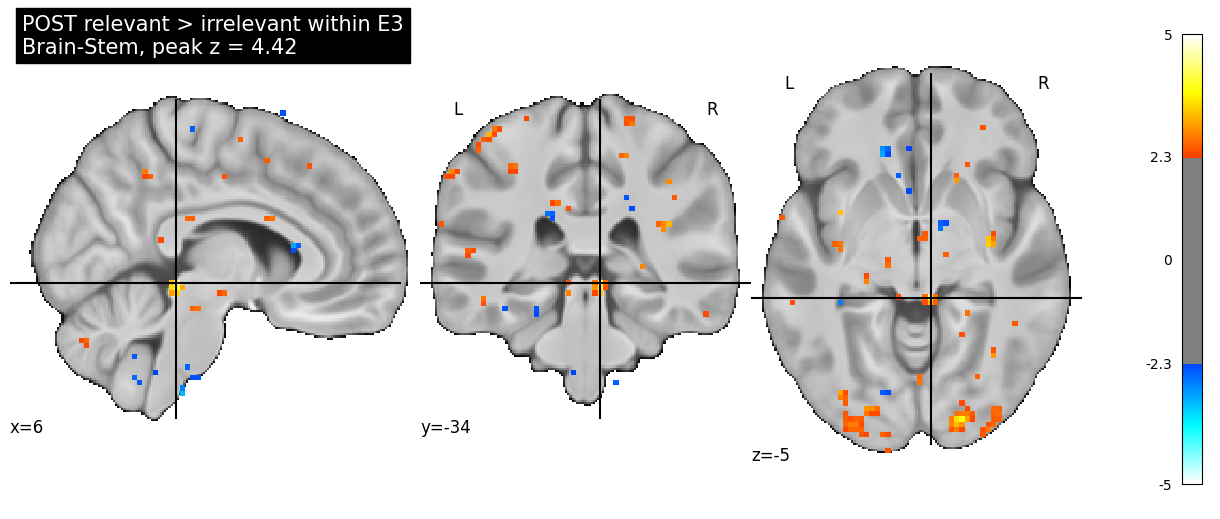

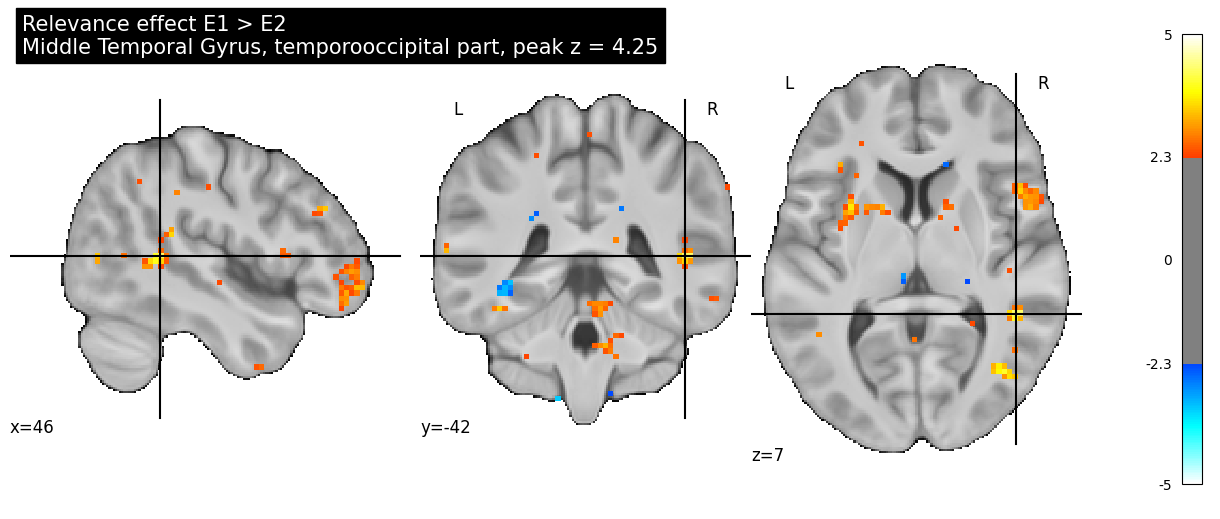

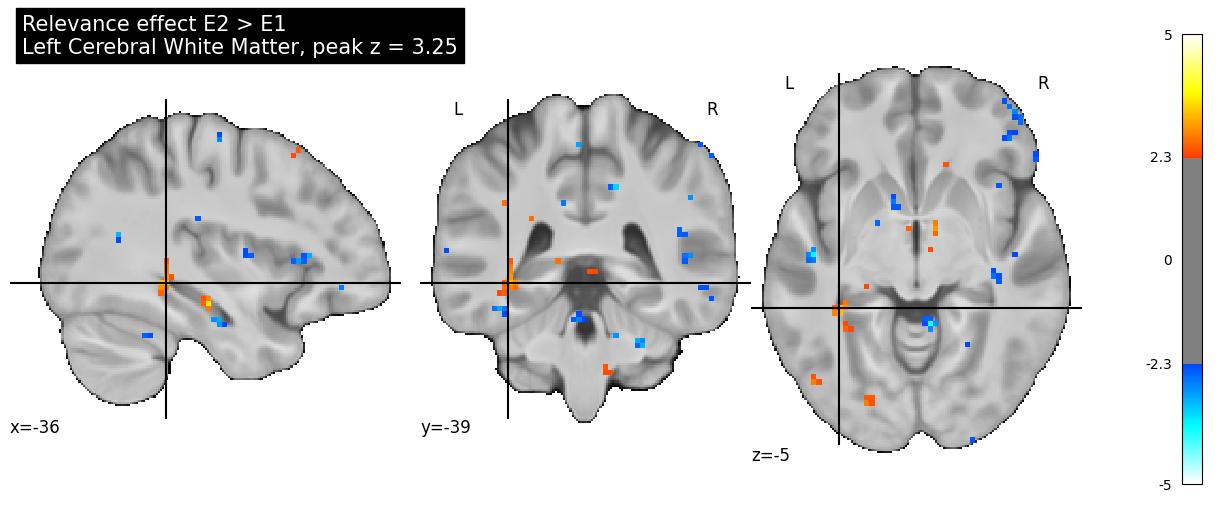

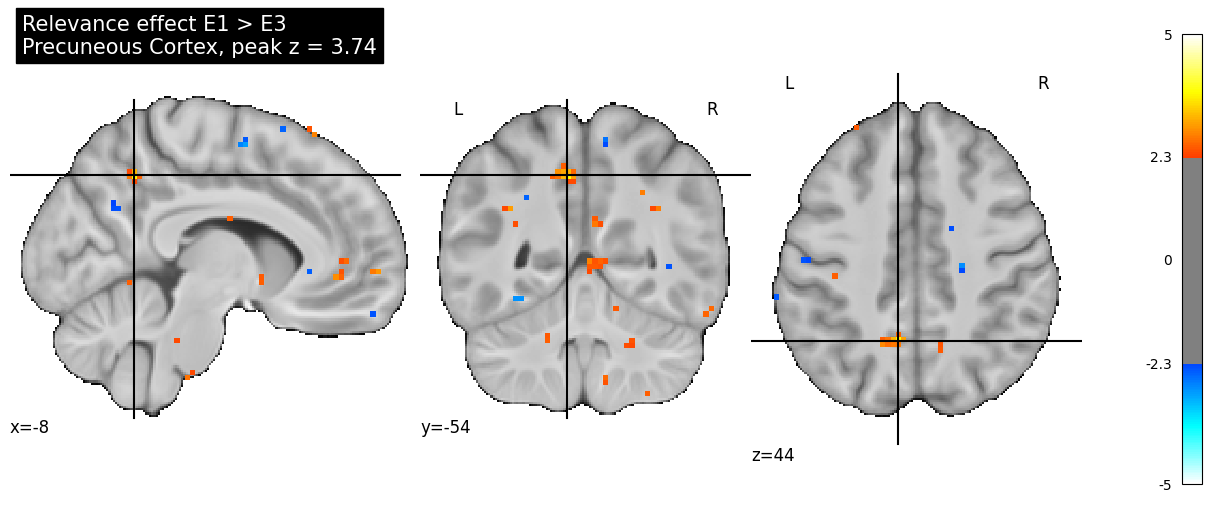

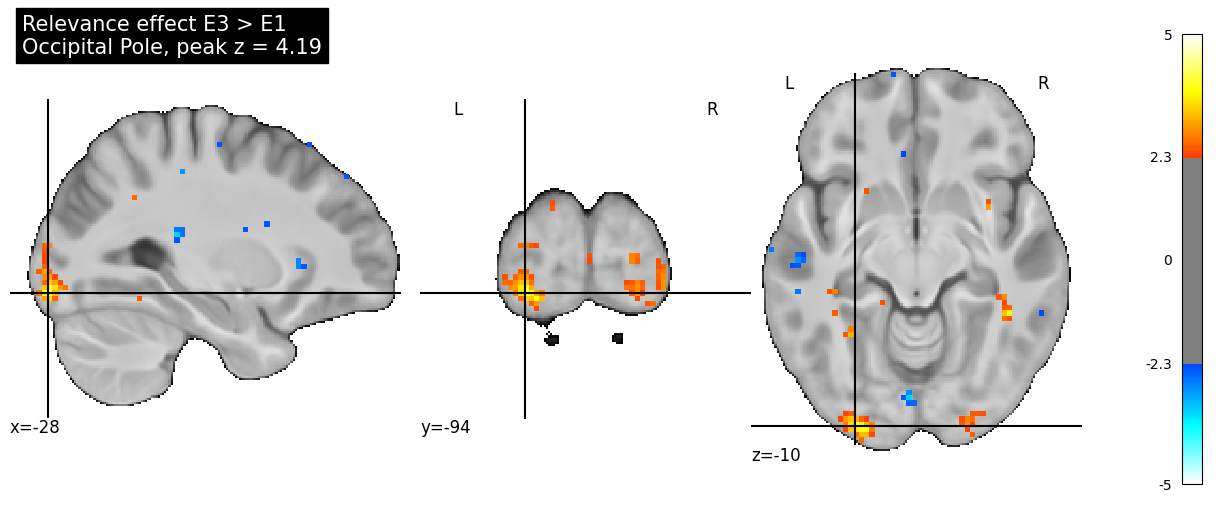

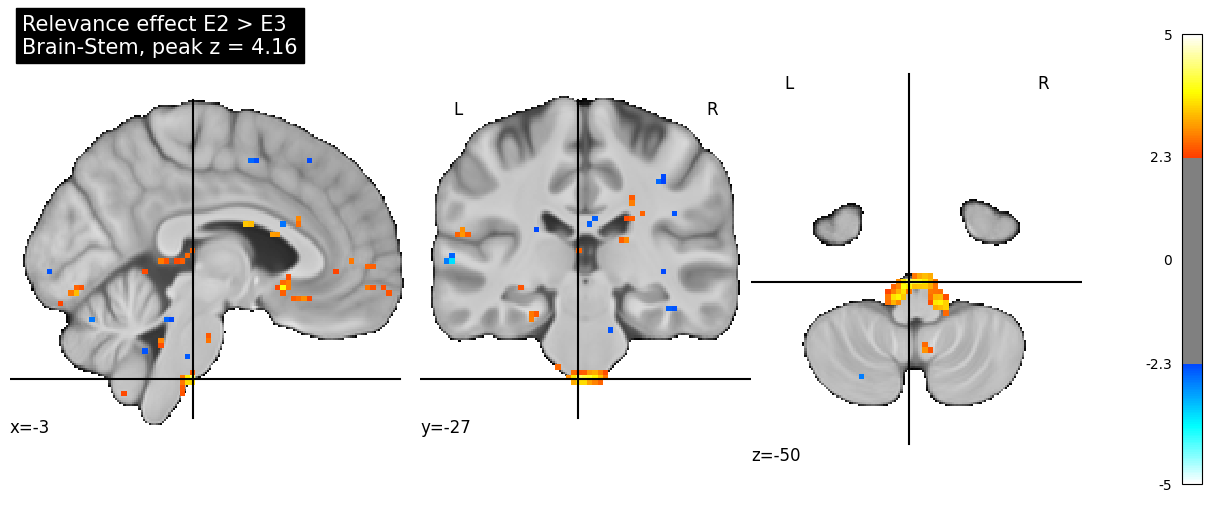

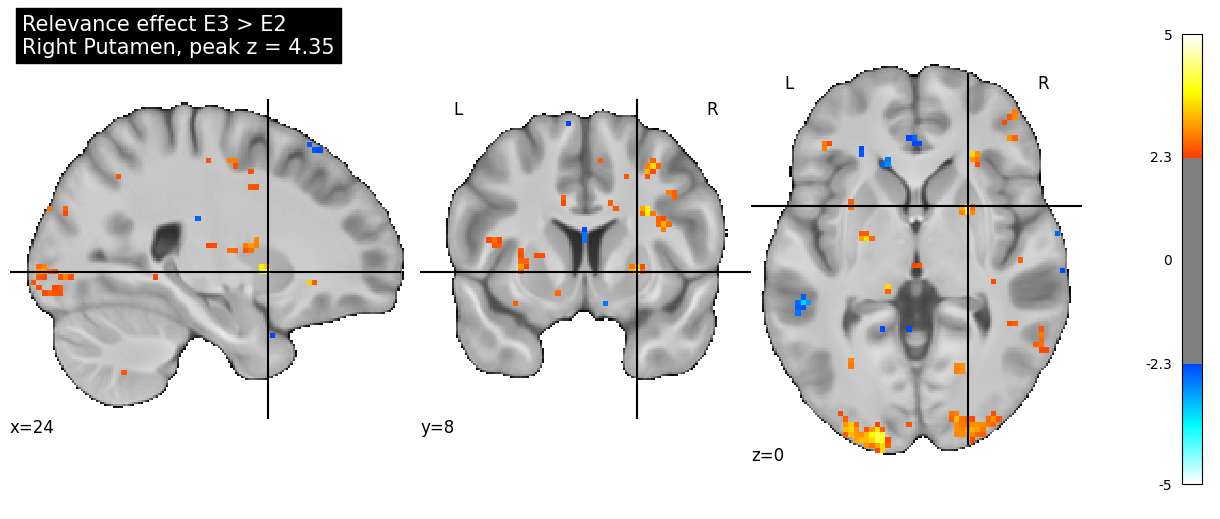

,contrast,figure_path,x,y,z,peak_z,atlas_label,background
0,post_rel_gt_irrel_avg,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,1.5,-47.0,42.0,4.465570,Precuneous Cortex,mean_T1w
1,post_rel_gt_irrel_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,21.5,-72.0,-35.5,4.069502,Background,mean_T1w
2,post_rel_gt_irrel_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,-38.5,30.5,47.0,3.772909,Middle Frontal Gyrus,mean_T1w
3,post_rel_gt_irrel_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,6.5,-34.5,-5.5,4.421704,Brain-Stem,mean_T1w
4,post_relIrrel_e1_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,46.5,-42.0,7.0,4.252445,"Middle Temporal Gyrus, temporooccipital part",mean_T1w
5,post_relIrrel_e2_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,-36.0,-39.5,-5.5,3.250756,Left Cerebral White Matter,mean_T1w
6,post_relIrrel_e1_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,-8.5,-54.5,44.5,3.740611,Precuneous Cortex,mean_T1w
7,post_relIrrel_e3_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,-28.5,-94.5,-10.5,4.187243,Occipital Pole,mean_T1w
8,post_relIrrel_e2_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,-3.5,-27.0,-50.5,4.163944,Brain-Stem,mean_T1w
9,post_relIrrel_e3_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/figures/post_relevance_episode_interaction_v...,24.0,8.0,-0.5,4.347035,Right Putamen,mean_T1w


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_figure_index_on_mean_T1w_smoothed5mm.csv


In [27]:
# ============================================================
# 11. Plot relevance × episode contrasts on mean T1w background
# ============================================================

main_contrasts = [
    "post_rel_gt_irrel_avg",
    "post_rel_gt_irrel_e1",
    "post_rel_gt_irrel_e2",
    "post_rel_gt_irrel_e3",
    "post_relIrrel_e1_gt_e2",
    "post_relIrrel_e2_gt_e1",
    "post_relIrrel_e1_gt_e3",
    "post_relIrrel_e3_gt_e1",
    "post_relIrrel_e2_gt_e3",
    "post_relIrrel_e3_gt_e2",
]

plot_title_map = {
    "post_rel_gt_irrel_avg": "POST relevant > irrelevant, averaged across E1/E2/E3",
    "post_rel_gt_irrel_e1": "POST relevant > irrelevant within E1",
    "post_rel_gt_irrel_e2": "POST relevant > irrelevant within E2",
    "post_rel_gt_irrel_e3": "POST relevant > irrelevant within E3",
    "post_relIrrel_e1_gt_e2": "Relevance effect E1 > E2",
    "post_relIrrel_e2_gt_e1": "Relevance effect E2 > E1",
    "post_relIrrel_e1_gt_e3": "Relevance effect E1 > E3",
    "post_relIrrel_e3_gt_e1": "Relevance effect E3 > E1",
    "post_relIrrel_e2_gt_e3": "Relevance effect E2 > E3",
    "post_relIrrel_e3_gt_e2": "Relevance effect E3 > E2",
}

plot_index_rows = []

for contrast_name in main_contrasts:
    subset = cluster_details_labeled.query(
        "contrast == @contrast_name and threshold_label == 'z_gt_2.33'"
    ).copy()

    if len(subset) == 0:
        print("No z > 2.33 clusters for", contrast_name)
        continue

    top = subset.sort_values("Peak Stat", ascending=False).iloc[0]
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    cut_coords = (float(top["X"]), float(top["Y"]), float(top["Z"]))

    atlas_label = top.get("harvard_oxford_cortical_label", "")
    if atlas_label == "Background":
        atlas_label = top.get("harvard_oxford_subcortical_label", "Background")

    title = (
        f"{plot_title_map[contrast_name]}\n"
        f"{atlas_label}, peak z = {float(top['Peak Stat']):.2f}"
    )
    fig_path = dirs["figures"] / f"{ANALYSIS_NAME}_{contrast_name}_top_peak_on_mean_T1w_{SMOOTHING_LABEL}.png"

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=cut_coords,
        title=title,
        threshold=2.33,
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        dim=-0.2,
    )

    plot_index_rows.append({
        "contrast": contrast_name,
        "figure_path": str(fig_path),
        "x": cut_coords[0],
        "y": cut_coords[1],
        "z": cut_coords[2],
        "peak_z": float(top["Peak Stat"]),
        "atlas_label": atlas_label,
        "background": "mean_T1w" if USE_MEAN_T1W_BACKGROUND else "MNI_template",
    })

plot_index = pd.DataFrame(plot_index_rows)
plot_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_figure_index_on_mean_T1w_{SMOOTHING_LABEL}.csv"
plot_index.to_csv(plot_index_path, index=False)

display(plot_index)
print("Saved:", plot_index_path)


Is the difference between relevant and irrelevant old images larger in episode 2 than in episode 1?

## Optional interactive views

These HTML views are useful for inspection but should not be the primary presentation figures.


In [28]:
# ============================================================
# 12. Save optional interactive views
# ============================================================

interactive_rows = []

for contrast_name in main_contrasts:
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    html_path = dirs["interactive"] / f"{ANALYSIS_NAME}_{contrast_name}_{SMOOTHING_LABEL}_interactive.html"
    view = make_interactive_view(z_map_path, threshold=2.33, title=plot_title_map[contrast_name])
    view.save_as_html(str(html_path))
    interactive_rows.append({"contrast": contrast_name, "interactive_html_path": str(html_path)})

interactive_index = pd.DataFrame(interactive_rows)
interactive_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_interactive_index_{SMOOTHING_LABEL}.csv"
interactive_index.to_csv(interactive_index_path, index=False)

display(interactive_index)
print("Saved:", interactive_index_path)


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWa

,contrast,interactive_html_path
0,post_rel_gt_irrel_avg,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
1,post_rel_gt_irrel_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
2,post_rel_gt_irrel_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
3,post_rel_gt_irrel_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
4,post_relIrrel_e1_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
5,post_relIrrel_e2_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
6,post_relIrrel_e1_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
7,post_relIrrel_e3_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
8,post_relIrrel_e2_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...
9,post_relIrrel_e3_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/interactive_views/post_relevance_episode_int...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/tables/post_relevance_episode_interaction_viewing_glm_interactive_index_smoothed5mm.csv


## Notebook conclusion

This notebook provides a structured POST-only relevance × episode interaction analysis.

The key outputs are:

- first-level POST relevance × episode contrast maps for all N=27 subjects;
- group-level maps for episode-specific relevance effects;
- all ordered pairwise relevance-by-episode interactions;
- threshold summaries and cluster tables;
- figures plotted on the common mean T1w background from Notebook 00.

Interpretation should remain cautious: these are exploratory whole-brain interaction contrasts unless corrected thresholds are survived.


In [29]:
# ============================================================
# 13. Save analysis manifest
# ============================================================

analysis_manifest = {
    "notebook": "07_post_relevance_episode_interaction_viewing_glm.ipynb",
    "analysis_name": ANALYSIS_NAME,
    "project_root": str(PROJECT_ROOT),
    "n_subjects": len(subjects),
    "subjects": subjects,
    "smoothing_fwhm": SMOOTHING_FWHM,
    "smoothing_label": SMOOTHING_LABEL,
    "runtime_flags": {
        "RUN_FIRST_LEVEL": RUN_FIRST_LEVEL,
        "OVERWRITE_FIRST_LEVEL": OVERWRITE_FIRST_LEVEL,
        "RUN_SECOND_LEVEL": RUN_SECOND_LEVEL,
        "OVERWRITE_SECOND_LEVEL": OVERWRITE_SECOND_LEVEL,
        "USE_MEAN_T1W_BACKGROUND": USE_MEAN_T1W_BACKGROUND,
    },
    "main_contrasts": {
        name: contrast_specs[name]
        for name in main_contrasts
        if name in contrast_specs
    },
    "key_outputs": {
        "contrast_definitions": str(contrast_table_path),
        "event_qc": str(event_qc_path),
        "all_events": str(all_events_path),
        "first_level_qc": str(first_level_qc_path),
        "first_level_contrast_qc": str(first_level_contrast_qc_path),
        "first_level_map_qc": str(map_qc_path),
        "second_level_table": str(second_level_table_path),
        "threshold_summary": str(threshold_summary_path),
        "cluster_summary": str(cluster_summary_path),
        "cluster_details": str(cluster_details_path),
        "cluster_details_labeled": str(cluster_details_labeled_path),
        "figure_index_on_mean_T1w": str(plot_index_path),
        "interactive_index": str(interactive_index_path),
        "mean_t1w_background": str(mean_t1w_path),
    },
}

analysis_manifest_path = dirs["restart"] / f"{ANALYSIS_NAME}_analysis_manifest.json"
with open(analysis_manifest_path, "w") as f:
    json.dump(analysis_manifest, f, indent=2)

print("Saved analysis manifest:")
print(analysis_manifest_path)


Saved analysis manifest:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_relevance_episode_interaction_viewing_glm/restart/post_relevance_episode_interaction_viewing_glm_analysis_manifest.json
